# 🪐 Crater Segmentation — Inception-Attention U-Net

**Project:** Comparative Study and Enhancement of Deep Learning Architectures for Planetary Crater Segmentation

---
**Pipeline:**
```
Input Images → Tiling + Copy-Paste Augmentation → Dataset & DataLoaders
→ InceptionAttentionUNet → Training (AMP + Deep Supervision) → TTA Evaluation → Visualisation
```

---
## Section 0 — Global Config

> **Set `MODEL_NAME` here. All cells below will use this model automatically.**

In [6]:
# ════════════════════════════════════════════════════════════════
#  ★  CHOOSE YOUR MODEL ★
# ════════════════════════════════════════════════════════════════
MODEL_NAME = 'ghost_mlp_segnet'
HOLDOUT_IMAGE_NAME = 'thm_dir_N00_330.png'
# Other options: 'transunet' | 'ms_inception_attention_unet' | 'ghost_mlp_segnet'
# ════════════════════════════════════════════════════════════════

print(f"✅ Selected model: {MODEL_NAME}")

✅ Selected model: ghost_mlp_segnet


---
## Section 1 — Setup & Imports

In [2]:
!pip install torch torchvision opencv-python tqdm matplotlib numpy thop --quiet

In [3]:
import os, sys, json, time, random, shutil, math, warnings
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.models import resnet50, ResNet50_Weights

from torch.cuda.amp import GradScaler, autocast

warnings.filterwarnings('ignore')

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()
print(f'✓ Device    : {DEVICE}')
print(f'✓ PyTorch   : {torch.__version__}')
print(f'✓ CUDA      : {torch.cuda.is_available()}')
print(f'✓ AMP (fp16): {USE_AMP}  — training will be {"faster (mixed precision)" if USE_AMP else "CPU mode"}')
print(f'✓ Model     : {MODEL_NAME}')

✓ Device    : cuda
✓ PyTorch   : 2.10.0+cu128
✓ CUDA      : True
✓ AMP (fp16): True  — training will be faster (mixed precision)
✓ Model     : ghost_mlp_segnet


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)
print('✓ Seed set to 42')

✓ Seed set to 42


---
## Section 2 — Training Configuration

All hyperparameters live here. `MODEL_NAME` from Section 0 is injected automatically.

In [5]:
@dataclass
class TrainConfig:
    # ── Paths ──────────────────────────────────────────────────
    tile_image_dir : str   = './tiles/images'
    tile_mask_dir  : str   = './tiles/masks'
    output_dir     : str   = './runs'
    holdout_image_dir : str   = './tiles_holdout/images'
    holdout_mask_dir  : str   = './tiles_holdout/masks'

    # ── Data split ─────────────────────────────────────────────
    train_ratio    : float = 0.75
    val_ratio      : float = 0.10
    # test = remainder

    use_online_aug = True
    
    # ── Training ───────────────────────────────────────────────
    epochs              : int   = 10     # more epochs — model is larger
    batch_size          : int   = 2      # slightly smaller due to larger model
    learning_rate       : float = 1e-4
    weight_decay        : float = 1e-5
    early_stop_patience : int   = 5

    # ── DataLoader ─────────────────────────────────────────────
    num_workers : int  = 2
    pin_memory  : bool = True

    # ── Loss weights (Tversky + BCE) ───────────────────────────
    bce_weight     : float = 0.3    # reduced; Tversky now leads
    tversky_weight : float = 0.7    # Tversky penalises FN harder
    tversky_alpha  : float = 0.4    # FP weight  (low = FP tolerated)
    tversky_beta   : float = 0.6    # FN weight  (high = FN penalised)
    pos_weight     : float = 10.0   # high weight for sparse rim pixels

    # ── Deep supervision ───────────────────────────────────────
    deep_sup_weight : float = 0.4   # auxiliary head loss weight

    # ── Model ──────────────────────────────────────────────────
    in_channels  : int = 1
    out_channels : int = 1
    seed         : int = 42

    # ── Injected from global MODEL_NAME ────────────────────────
    model_name : str = MODEL_NAME

CFG = TrainConfig()
print(f'✓ Config loaded  →  model_name = {CFG.model_name}')
print(f'   epochs={CFG.epochs}  batch={CFG.batch_size}  lr={CFG.learning_rate}')
print(f'   loss=BCE({CFG.bce_weight}) + Tversky({CFG.tversky_weight}, α={CFG.tversky_alpha}, β={CFG.tversky_beta})')
print(f'   deep_supervision_weight={CFG.deep_sup_weight}')

✓ Config loaded  →  model_name = ghost_mlp_segnet
   epochs=10  batch=2  lr=0.0001
   loss=BCE(0.3) + Tversky(0.7, α=0.4, β=0.6)
   deep_supervision_weight=0.4


---
## Section 3 — Tiling + Copy-Paste Augmentation

> **Update the paths below to match your system before running.**  
> Skip this section (don't run `run_tiling()`) if tiles are already generated.

In [6]:
# ── Tiling paths ──────────────────────────────────────────────────────────────
IMAGE_DIR = r"/kaggle/input/datasets/sahibjparmar/mars-crater-dataset-for-semantic-segmentation/Dataset/Images"
MASK_DIR  = r"/kaggle/input/datasets/sahibjparmar/mars-crater-dataset-for-semantic-segmentation/Dataset/Mars_Crater_Segmentation_Dataset_02-32_km_radius/edge_thicker"

OUTPUT_IMAGE_DIR = "./tiles/images"
OUTPUT_MASK_DIR  = "./tiles/masks"

TILE_SIZE             = 512
STRIDE                = 512      # no overlap; set < TILE_SIZE for overlap
ENABLE_COPY_PASTE     = True
PASTES_PER_IMAGE      = 3
AUGMENTED_COPIES      = 2
MIN_CRATER_PIXELS     = 30
BLEND_FEATHER_RADIUS  = 5
MAX_PASTE_ATTEMPTS    = 10
BLACK_STRIP_THRESHOLD = 0.15
BLACK_PIXEL_VALUE     = 10

os.makedirs(OUTPUT_IMAGE_DIR, exist_ok=True)
os.makedirs(OUTPUT_MASK_DIR,  exist_ok=True)
print('✓ Output directories ready')

✓ Output directories ready


In [7]:
# ── Artifact Detection ────────────────────────────────────────────────────────
def has_black_strip(image: np.ndarray, threshold=BLACK_STRIP_THRESHOLD) -> bool:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image
    return (gray < BLACK_PIXEL_VALUE).sum() / gray.size > threshold

class CraterLibrary:
    def __init__(self): self.craters = []
    def extract_from_tile(self, image: np.ndarray, mask: np.ndarray):
        _, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        for i in range(1, len(stats)):
            x, y, w, h, area = stats[i]
            if area < MIN_CRATER_PIXELS: continue
            pad = max(5, int(max(w, h) * 0.1))
            x1, y1 = max(0, x-pad), max(0, y-pad)
            x2, y2 = min(image.shape[1], x+w+pad), min(image.shape[0], y+h+pad)
            self.craters.append({'img': image[y1:y2, x1:x2].copy(),
                                 'mask': mask[y1:y2, x1:x2].copy(),
                                 'radius': int(max(w, h) / 2), 'area': area})
    def sample(self, prefer_small=True):
        if not self.craters: return None
        if prefer_small and random.random() < 0.65:
            radii = np.array([c['radius'] for c in self.craters], dtype=float)
            weights = 1.0 / (radii + 1e-6); weights /= weights.sum()
            idx = np.random.choice(len(self.craters), p=weights)
        else:
            idx = random.randint(0, len(self.craters) - 1)
        return self.craters[idx]
    def __len__(self): return len(self.craters)

def gaussian_feather_mask(mask_patch, radius):
    blurred = cv2.GaussianBlur(mask_patch.astype(np.float32), (2*radius+1, 2*radius+1), sigmaX=radius)
    return np.clip(blurred / (blurred.max() + 1e-6), 0, 1)

def paste_overlaps_existing(target_mask, y1, x1, ch, cw):
    return (target_mask[y1:y1+ch, x1:x1+cw] > 0).any()

def copy_paste_augment(target_img, target_mask, library, n_pastes=PASTES_PER_IMAGE):
    aug_img  = target_img.copy().astype(np.float32)
    aug_mask = target_mask.copy()
    H, W     = aug_img.shape[:2]
    for _ in range(n_pastes):
        crater = library.sample(prefer_small=True)
        if crater is None: break
        c_img, c_mask = crater['img'], crater['mask']
        ch, cw = c_img.shape[:2]
        if ch >= H or cw >= W: continue
        placed = False
        for _ in range(MAX_PASTE_ATTEMPTS):
            y1 = random.randint(0, H - ch); x1 = random.randint(0, W - cw)
            if not paste_overlaps_existing(aug_mask, y1, x1, ch, cw):
                placed = True; break
        if not placed: continue
        weight = gaussian_feather_mask(c_mask, BLEND_FEATHER_RADIUS)
        if aug_img.ndim == 3 and c_img.ndim == 2: c_img = cv2.cvtColor(c_img, cv2.COLOR_GRAY2BGR)
        elif aug_img.ndim == 2 and c_img.ndim == 3: c_img = cv2.cvtColor(c_img, cv2.COLOR_BGR2GRAY)
        if aug_img.ndim == 3:
            w3 = weight[:, :, np.newaxis]
            aug_img[y1:y1+ch, x1:x1+cw] = (w3*c_img.astype(np.float32) + (1-w3)*aug_img[y1:y1+ch, x1:x1+cw])
        else:
            aug_img[y1:y1+ch, x1:x1+cw] = (weight*c_img.astype(np.float32) + (1-weight)*aug_img[y1:y1+ch, x1:x1+cw])
        aug_mask[y1:y1+ch, x1:x1+cw] = np.maximum(aug_mask[y1:y1+ch, x1:x1+cw], c_mask)
    return aug_img.astype(np.uint8), aug_mask

def get_base_name(filename): return os.path.splitext(filename)[0]
def find_mask(image_base, mask_files):
    for m in mask_files:
        if image_base in m: return m
    return None

def tile_image_and_mask(image_path, mask_path, base_name, library):
    image = cv2.imread(image_path)
    mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if image is None or mask is None:
        print(f'  [ERROR] Cannot read: {image_path}'); return 0, 0
    h, w = image.shape[:2]; orig_count = aug_count = 0
    for y in range(0, h - TILE_SIZE + 1, STRIDE):
        for x in range(0, w - TILE_SIZE + 1, STRIDE):
            img_patch  = image[y:y+TILE_SIZE, x:x+TILE_SIZE]
            mask_patch = mask[y:y+TILE_SIZE,  x:x+TILE_SIZE]
            if (mask_patch > 0).sum() < 10 or has_black_strip(img_patch): continue
            name = f'{base_name}_x{x}_y{y}.png'
            cv2.imwrite(os.path.join(OUTPUT_IMAGE_DIR, name), img_patch)
            cv2.imwrite(os.path.join(OUTPUT_MASK_DIR,  name), mask_patch)
            orig_count += 1; library.extract_from_tile(img_patch, mask_patch)
            if ENABLE_COPY_PASTE and len(library) > 5:
                for aug_idx in range(AUGMENTED_COPIES):
                    aug_img, aug_mask = copy_paste_augment(img_patch, mask_patch, library)
                    if (aug_mask > 0).sum() < 10: continue
                    aug_name = f'{base_name}_x{x}_y{y}_aug{aug_idx}.png'
                    cv2.imwrite(os.path.join(OUTPUT_IMAGE_DIR, aug_name), aug_img)
                    cv2.imwrite(os.path.join(OUTPUT_MASK_DIR,  aug_name), aug_mask)
                    aug_count += 1
    return orig_count, aug_count

def run_tiling():
    image_files = os.listdir(IMAGE_DIR); mask_files = os.listdir(MASK_DIR)
    library = CraterLibrary(); total_orig = total_aug = skipped = 0
    for img_file in tqdm(image_files, desc='Tiling images'):
        base = get_base_name(img_file); mask_file = find_mask(base, mask_files)
        if mask_file is None: skipped += 1; continue
        orig, aug = tile_image_and_mask(os.path.join(IMAGE_DIR, img_file),
                                        os.path.join(MASK_DIR,  mask_file), base, library)
        total_orig += orig; total_aug += aug
    print(f'\n{"="*45}')
    print(f'  Original tiles : {total_orig:,}')
    print(f'  Augmented tiles: {total_aug:,}')
    print(f'  Total tiles    : {total_orig + total_aug:,}')
    print(f'  Crater library : {len(library):,} instances')
    print(f'{"="*45}')

# ▶ Run tiling — comment out if tiles already exist
run_tiling()

Tiling images:   0%|          | 0/24 [00:00<?, ?it/s]


  Original tiles : 4,822
  Augmented tiles: 9,640
  Total tiles    : 14,462
  Crater library : 33,009 instances


---
## Section 4 — Dataset & DataLoaders

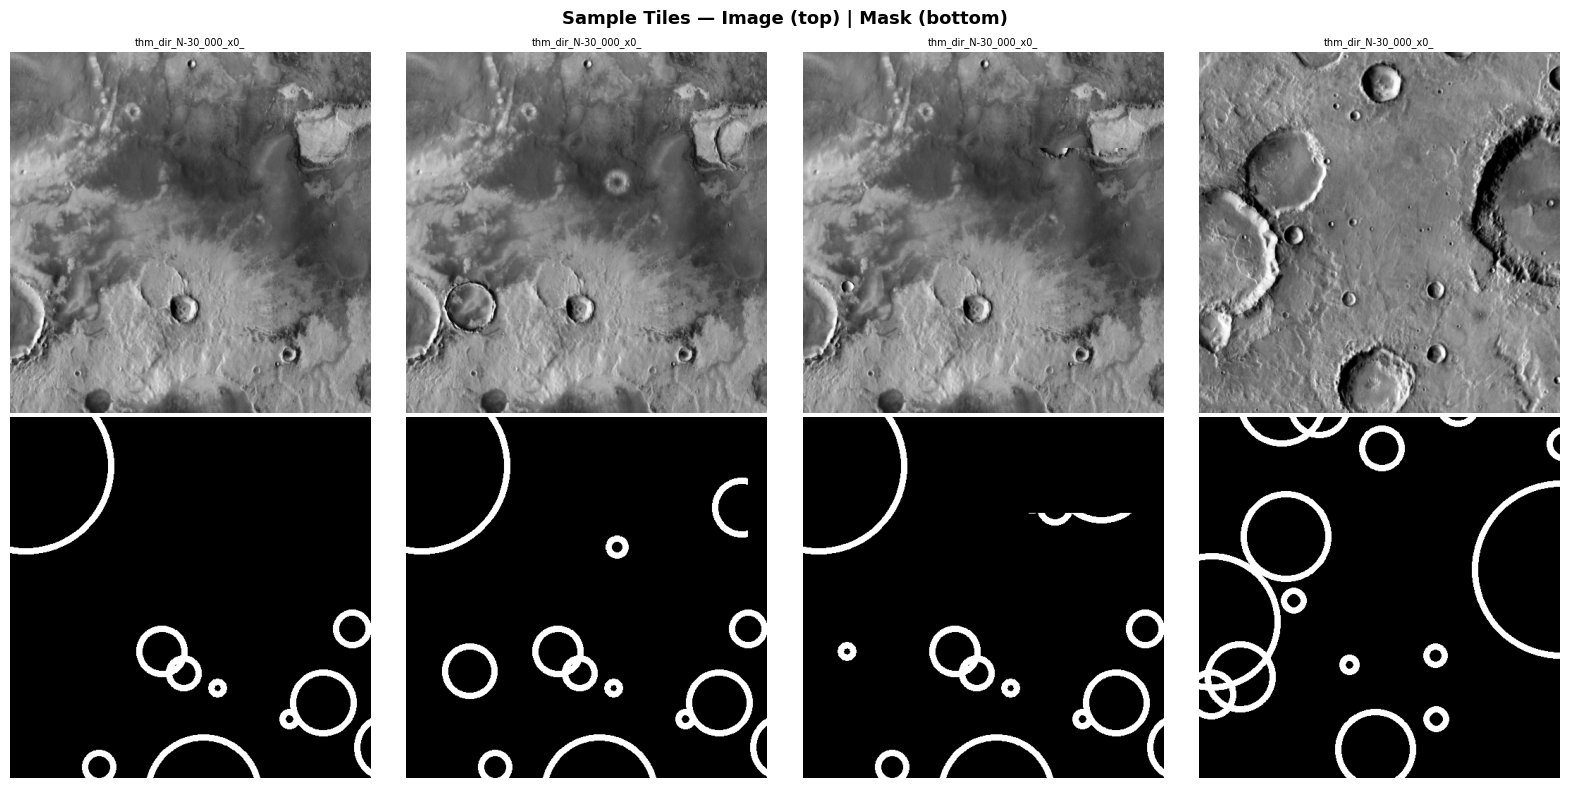

✓ Dataset classes defined


In [8]:
class CraterDataset(Dataset):
    """Reads pre-tiled images and binary rim masks."""
    def __init__(self, image_dir, mask_dir, augment=False):
        self.image_dir   = Path(image_dir)
        self.mask_dir    = Path(mask_dir)
        self.augment     = augment
        self.image_paths = sorted(self.image_dir.glob('*.png'))
        assert len(self.image_paths) > 0, f'No tiles found in {image_dir}'

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img_path  = self.image_paths[idx]
        mask_path = self.mask_dir / img_path.name
        img  = cv2.imread(str(img_path),  cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        mask = (cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) > 127).astype(np.float32)
        if self.augment:
            img, mask = self._augment(img, mask)
        return torch.from_numpy(img).unsqueeze(0), torch.from_numpy(mask).unsqueeze(0)

    def _augment(self, img, mask):
        # if random.random() > 0.6:
        #     img = np.clip(img * random.uniform(0.8, 1.2), 0, 1)
        # if random.random() > 0.7:
        #     img = np.clip(img + np.random.normal(0, 0.02, img.shape).astype(np.float32), 0, 1)
        # return img, mask

        # 1. Spatial Augmentations (Flips & Rotations)
        if random.random() > 0.5: img, mask = np.fliplr(img).copy(), np.fliplr(mask).copy()
        if random.random() > 0.5: img, mask = np.flipud(img).copy(), np.flipud(mask).copy()
        if random.random() > 0.5:
            k = random.choice([1, 2, 3])
            img, mask = np.rot90(img, k).copy(), np.rot90(mask, k).copy()

        # 2. "Color Jitter" for Grayscale (Brightness & Contrast)
        if random.random() > 0.5:
            # Random Contrast (Multiplicative scaling)
            contrast_factor = random.uniform(0.7, 1.3)
            img = img * contrast_factor
            
            # Random Brightness (Additive shifting)
            brightness_factor = random.uniform(-0.15, 0.15)
            img = img + brightness_factor

        # 3. Sensor Noise (Simulates grainy satellite transmission)
        if random.random() > 0.7:
            noise = np.random.normal(0, 0.02, img.shape).astype(np.float32)
            img = img + noise

        # 4. Clipping (Ensure pixel values stay strictly between 0.0 and 1.0)
        img = np.clip(img, 0, 1)

        return img, mask


def make_dataloaders(cfg):
    full_ds = CraterDataset(cfg.tile_image_dir, cfg.tile_mask_dir)
    n       = len(full_ds)
    n_train = int(n * cfg.train_ratio)
    n_val   = int(n * cfg.val_ratio)
    n_test  = n - n_train - n_val
    torch.manual_seed(cfg.seed)
    train_ds, val_ds, test_ds = random_split(full_ds, [n_train, n_val, n_test])

    train_aug    = CraterDataset(cfg.tile_image_dir, cfg.tile_mask_dir, augment=cfg.use_online_aug)
    train_subset = Subset(train_aug, train_ds.indices)
    pw = cfg.num_workers > 0

    train_loader = DataLoader(train_subset, batch_size=cfg.batch_size, shuffle=True,
                              num_workers=cfg.num_workers, pin_memory=cfg.pin_memory,
                              drop_last=True, persistent_workers=pw)
    val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size * 2, shuffle=False,
                              num_workers=cfg.num_workers, pin_memory=cfg.pin_memory,
                              persistent_workers=pw)
    test_loader  = DataLoader(test_ds, batch_size=cfg.batch_size * 2, shuffle=False,
                              num_workers=cfg.num_workers, persistent_workers=pw)

    print(f'  Train: {len(train_subset):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}')
    return train_loader, val_loader, test_loader, test_ds.indices


def preview_tiles(n=4):
    img_dir  = Path(CFG.tile_image_dir)
    mask_dir = Path(CFG.tile_mask_dir)
    paths = sorted(img_dir.glob('*.png'))[:n]
    if not paths:
        print('No tiles found — run tiling first.'); return
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    fig.suptitle('Sample Tiles — Image (top) | Mask (bottom)', fontsize=13, fontweight='bold')
    for i, p in enumerate(paths):
        img  = cv2.imread(str(p),              cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_dir / p.name), cv2.IMREAD_GRAYSCALE)
        axes[0, i].imshow(img,  cmap='gray'); axes[0, i].axis('off')
        axes[0, i].set_title(p.name[:20], fontsize=7)
        axes[1, i].imshow(mask, cmap='gray'); axes[1, i].axis('off')
    plt.tight_layout(); plt.show()

preview_tiles()
print('✓ Dataset classes defined')

---
## Section 5 — Model Architectures

| Model | Key idea |
|---|---|
| `unet` | Standard U-Net — encoder/decoder + skip connections |
| `dense_unet` | DenseNet blocks — improved gradient flow & feature reuse |
| `transunet` | ResNet-50 CNN + Vision Transformer |
| `attention_unet` | U-Net + CBAM self-attention on every skip connection |
| `inception_attention_unet` | Inception encoder + decoder-guided attention gates + deep supervision |
|`multi_scale_attention_unet`| - Multi-Scale Attention U-Net Architecture

In [9]:
# ── Shared Building Blocks ────────────────────────────────────────────────────
class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, padding=1, dilation=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, padding=padding, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.block(x)

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(ConvBnRelu(in_ch, out_ch), ConvBnRelu(out_ch, out_ch))
    def forward(self, x): return self.block(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
        return self.conv(torch.cat([skip, x], dim=1))

print('✓ Shared blocks defined')

✓ Shared blocks defined


In [10]:
# ── 1. Baseline U-Net ─────────────────────────────────────────────────────────
class UNet(nn.Module):
    """Standard U-Net — performance baseline."""
    def __init__(self, in_channels=1, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.encoders = nn.ModuleList(); self.pools = nn.ModuleList(); self.decoders = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch, f)); self.pools.append(nn.MaxPool2d(2)); ch = f
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        rev = list(reversed(features)); in_ch = features[-1] * 2
        for f in rev:
            self.decoders.append(UpBlock(in_ch, f, f)); in_ch = f
        self.head = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x); skips.append(x); x = pool(x)
        x = self.bottleneck(x)
        for dec, skip in zip(self.decoders, reversed(skips)):
            x = dec(x, skip)
        return self.head(x)

print('✓ UNet defined')

✓ UNet defined


In [11]:
# ── 2. DenseNet U-Net ─────────────────────────────────────────────────────────
class DenseLayer(nn.Module):
    def __init__(self, in_ch, growth_rate, dropout=0.2):
        super().__init__()
        self.layer = nn.Sequential(
            nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, growth_rate, 3, padding=1, bias=False),
            nn.Dropout2d(dropout))
    def forward(self, x): return torch.cat([x, self.layer(x)], dim=1)

class DenseBlock(nn.Module):
    def __init__(self, in_ch, growth_rate=32, num_layers=4, dropout=0.2):
        super().__init__()
        layers, ch = [], in_ch
        for _ in range(num_layers):
            layers.append(DenseLayer(ch, growth_rate, dropout)); ch += growth_rate
        self.block = nn.Sequential(*layers); self.out_channels = ch
    def forward(self, x): return self.block(x)

class TransitionDown(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.MaxPool2d(2))
    def forward(self, x): return self.block(x)

class TransitionUp(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = nn.Conv2d(in_ch, out_ch, 1, bias=False)
    def forward(self, x, skip):
        x = self.up(x)
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
        return self.conv(torch.cat([x, skip], dim=1))

class DenseUNet(nn.Module):
    """DenseNet-based U-Net."""
    def __init__(self, in_channels=1, out_channels=1, init_features=48, growth_rate=16, num_layers=4):
        super().__init__()
        self.init_conv = ConvBnRelu(in_channels, init_features)
        self.enc_blocks = nn.ModuleList(); self.tds = nn.ModuleList()
        self.skip_channels = []; ch = init_features
        for _ in range(4):
            db = DenseBlock(ch, growth_rate, num_layers)
            self.enc_blocks.append(db); self.skip_channels.append(db.out_channels)
            td = TransitionDown(db.out_channels, db.out_channels // 2)
            self.tds.append(td); ch = db.out_channels // 2
        self.bottleneck = DenseBlock(ch, growth_rate, num_layers * 2)
        ch = self.bottleneck.out_channels
        self.tus = nn.ModuleList(); self.dec_blocks = nn.ModuleList()
        for skip_ch in reversed(self.skip_channels):
            self.tus.append(TransitionUp(ch + skip_ch, skip_ch))
            db = DenseBlock(skip_ch, growth_rate, num_layers)
            self.dec_blocks.append(db); ch = db.out_channels
        self.head = nn.Conv2d(ch, out_channels, 1)

    def forward(self, x):
        x = self.init_conv(x); skips = []
        for enc, td in zip(self.enc_blocks, self.tds):
            x = enc(x); skips.append(x); x = td(x)
        x = self.bottleneck(x)
        for tu, dec, skip in zip(self.tus, self.dec_blocks, reversed(skips)):
            x = tu(x, skip); x = dec(x)
        return self.head(x)

print('✓ DenseUNet defined')

✓ DenseUNet defined


In [12]:
# ── 3. TransUNet ──────────────────────────────────────────────────────────────
class PatchEmbedding(nn.Module):
    def __init__(self, in_ch, d_model, patch_size=1):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, d_model, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        x = self.proj(x); B, D, h, w = x.shape
        return x.flatten(2).transpose(1, 2), h, w

class TransformerBlock(nn.Module):
    def __init__(self, d_model=768, num_heads=12, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn  = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        mlp_dim = int(d_model * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, d_model), nn.Dropout(dropout))
    def forward(self, x):
        xn = self.norm1(x); attn_out, _ = self.attn(xn, xn, xn)
        x = x + attn_out
        return x + self.ffn(self.norm2(x))

class TransUNet(nn.Module):
    """TransUNet — ResNet-50 CNN encoder + Vision Transformer."""
    def __init__(self, in_channels=1, out_channels=1, img_size=512,
                 d_model=768, num_heads=12, num_layers=12, dropout=0.1):
        super().__init__()
        backbone = resnet50(weights=ResNet50_Weights.DEFAULT)
        backbone.conv1 = nn.Conv2d(in_channels, 64, 7, stride=2, padding=3, bias=False)
        self.enc0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)
        self.pool = backbone.maxpool
        self.enc1 = backbone.layer1; self.enc2 = backbone.layer2; self.enc3 = backbone.layer3
        self.patch_embed = PatchEmbedding(1024, d_model, patch_size=1)
        n_patches = (img_size // 16) ** 2
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.transformer = nn.Sequential(
            *[TransformerBlock(d_model, num_heads, dropout=dropout) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.proj_back = nn.Conv2d(d_model, 512, 1)
        self.dec3 = UpBlock(512, 1024, 256); self.dec2 = UpBlock(256, 512, 128)
        self.dec1 = UpBlock(128, 256, 64);   self.dec0 = UpBlock(64, 64, 32)
        self.head = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(16, out_channels, 1))

    def forward(self, x):
        B = x.shape[0]
        s0 = self.enc0(x); s1 = self.enc1(self.pool(s0))
        s2 = self.enc2(s1); s3 = self.enc3(s2)
        tokens, h, w = self.patch_embed(s3)
        pos = self.pos_embed
        if tokens.shape[1] != pos.shape[1]:
            pos = F.interpolate(
                pos.reshape(1, int(pos.shape[1]**0.5), int(pos.shape[1]**0.5), -1).permute(0,3,1,2),
                size=(h, w), mode='bilinear', align_corners=True
            ).permute(0, 2, 3, 1).reshape(1, h*w, -1)
        tokens = self.transformer(tokens + pos); tokens = self.norm(tokens)
        feat   = tokens.transpose(1, 2).reshape(B, -1, h, w)
        feat   = self.proj_back(feat)
        x = self.dec3(feat, s3); x = self.dec2(x, s2)
        x = self.dec1(x, s1);   x = self.dec0(x, s0)
        return self.head(x)

print('✓ TransUNet defined')

✓ TransUNet defined


In [13]:
# ── 4. Attention U-Net (CBAM skip attention) ──────────────────────────────────
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 4)
        self.avg_pool = nn.AdaptiveAvgPool2d(1); self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(channels, mid, bias=False),
                                nn.ReLU(inplace=True), nn.Linear(mid, channels, bias=False))
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        scale = self.sigmoid(self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x)))
        return x * scale.unsqueeze(-1).unsqueeze(-1)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        desc = torch.cat([x.mean(dim=1, keepdim=True), x.max(dim=1, keepdim=True).values], dim=1)
        return x * self.sigmoid(self.conv(desc))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction); self.sa = SpatialAttention()
    def forward(self, x): return self.sa(self.ca(x))

class AttentionUpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.attn = CBAM(skip_ch)
        self.conv = DoubleConv(in_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        x    = self.up(x)
        x    = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
        skip = self.attn(skip)
        return self.conv(torch.cat([skip, x], dim=1))

class AttentionUNet(nn.Module):
    """U-Net + CBAM attention on every skip connection."""
    def __init__(self, in_channels=1, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.encoders = nn.ModuleList(); self.pools = nn.ModuleList(); self.decoders = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch, f)); self.pools.append(nn.MaxPool2d(2)); ch = f
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        rev = list(reversed(features)); in_ch = features[-1] * 2
        for f in rev:
            self.decoders.append(AttentionUpBlock(in_ch, f, f)); in_ch = f
        self.head = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x); skips.append(x); x = pool(x)
        x = self.bottleneck(x)
        for dec, skip in zip(self.decoders, reversed(skips)):
            x = dec(x, skip)
        return self.head(x)

print('✓ AttentionUNet defined')

✓ AttentionUNet defined


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# ──  Inception-Attention U-Net  ──────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
#
# Key innovations over vanilla U-Net:
#   (a) InceptionBlock replaces DoubleConv in every encoder stage — captures
#       small craters via 1×1 branch, medium via 3×3, larger via dilated-3×3
#       (d=2, effective 5×5 receptive field) with fewer parameters than true
#       5×5, and dominant textures via MaxPool→1×1.
#   (b) AttentionGate on every skip connection uses the decoder's gating signal
#       to spatially suppress non-crater background before concatenation.
#       Unlike CBAM (self-attention), this gate is guided by what the decoder
#       is currently trying to reconstruct — more targetted suppression.
#   (c) Deep supervision: auxiliary 1×1 segmentation heads at each decoder
#       level; their loss is combined with the final head loss. Forces the
#       network to learn crater-relevant features at every scale.
# ──────────────────────────────────────────────────────────────────────────────

class InceptionBlock(nn.Module):
    """
    Multi-scale encoder block that replaces DoubleConv.

    Four parallel branches (all with 1×1 bottleneck to control channel cost):
      1. 1×1 conv         — pointwise / fine detail
      2. 1×1 → 3×3        — small craters (~10-50 px rim width)
      3. 1×1 → 3×3 d=2    — medium craters (same params, 5×5 effective RF)
      4. MaxPool → 1×1    — dominant structural patterns
    All branches concatenated, then projected back to `out_ch` with BN+ReLU.
    """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        branch_ch = max(out_ch // 4, 16)   # each branch contributes out_ch/4 channels

        # Branch 1: 1×1 pointwise
        self.b1 = ConvBnRelu(in_ch, branch_ch, kernel=1, padding=0)

        # Branch 2: 1×1 bottleneck → 3×3  (local context)
        self.b2 = nn.Sequential(
            ConvBnRelu(in_ch, branch_ch, kernel=1, padding=0),
            ConvBnRelu(branch_ch, branch_ch, kernel=3, padding=1))

        # Branch 3: 1×1 bottleneck → 3×3 dilated d=2  (medium range, 5×5 RF)
        self.b3 = nn.Sequential(
            ConvBnRelu(in_ch, branch_ch, kernel=1, padding=0),
            ConvBnRelu(branch_ch, branch_ch, kernel=3, padding=2, dilation=2))

        # Branch 4: 3×3 MaxPool → 1×1 projection  (pooled dominant features)
        self.b4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            ConvBnRelu(in_ch, branch_ch, kernel=1, padding=0))

        # Project concatenated branches back to out_ch
        self.fuse = nn.Sequential(
            nn.Conv2d(branch_ch * 4, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True))

    def forward(self, x):
        return self.fuse(torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4(x)], dim=1))


class AttentionGate(nn.Module):
    """
    Decoder-guided spatial attention gate (Oktay et al., 2018).

    Unlike CBAM which is self-attention on the skip features alone, this gate
    takes TWO inputs:
      - skip (x_l): high-resolution skip connection from the encoder
      - gate (g):   upsampled feature from the decoder (what the decoder wants)

    The gate learns to suppress skip positions that the decoder doesn't need,
    which is especially effective for small craters in cluttered terrain.

    Output: elementwise-gated skip, same spatial size as input skip.
    """
    def __init__(self, skip_ch: int, gate_ch: int, inter_ch: int = None):
        super().__init__()
        inter_ch = inter_ch or skip_ch // 2

        # Linear projections (no bias, BN handles offset)
        self.W_skip = nn.Sequential(
            nn.Conv2d(skip_ch, inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch))
        self.W_gate = nn.Sequential(
            nn.Conv2d(gate_ch, inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch))

        # Output: per-spatial-position scalar attention weight in (0, 1)
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid())

        self.relu = nn.ReLU(inplace=True)

    def forward(self, skip, gate):
        # Upsample gate to match skip resolution if needed
        if gate.shape[2:] != skip.shape[2:]:
            gate = F.interpolate(gate, size=skip.shape[2:], mode='bilinear', align_corners=True)
        alpha = self.psi(self.relu(self.W_skip(skip) + self.W_gate(gate)))
        return skip * alpha    # gated skip: suppress irrelevant positions


class InceptionDecoderBlock(nn.Module):
    """
    Decoder block with:
      - Bilinear upsampling
      - AttentionGate on the skip connection (decoder-guided)
      - Concat + DoubleConv to fuse gated skip with upsampled features
      - Auxiliary segmentation head for deep supervision
    """
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up      = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.gate    = AttentionGate(skip_ch=skip_ch, gate_ch=in_ch)
        self.conv    = DoubleConv(in_ch + skip_ch, out_ch)
        # Auxiliary head — used only during training for deep supervision
        self.aux_head = nn.Conv2d(out_ch, 1, kernel_size=1)

    def forward(self, x, skip):
        x    = self.up(x)
        x    = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
        skip = self.gate(skip, gate=x)          # gate skip with decoder signal
        feat = self.conv(torch.cat([skip, x], dim=1))
        aux  = self.aux_head(feat)              # auxiliary logits at this scale
        return feat, aux


class InceptionAttentionUNet(nn.Module):
    """
    Inception-Attention U-Net with deep supervision.

    Encoder: 4× InceptionBlock (multi-scale) + MaxPool
    Bottleneck: DoubleConv
    Decoder: 4× InceptionDecoderBlock (decoder-guided attention gate + auxiliary head)
    Final head: 1×1 conv → segmentation logits

    Forward returns:
      - Training:   (final_logits, [aux1, aux2, aux3, aux4])  — for deep supervision loss
      - Inference:  final_logits only  (call model.eval() first)
    """
    def __init__(self, in_channels=1, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.encoders = nn.ModuleList()
        self.pools    = nn.ModuleList()
        self.decoders = nn.ModuleList()

        ch = in_channels
        for f in features:
            self.encoders.append(InceptionBlock(ch, f))
            self.pools.append(nn.MaxPool2d(2))
            ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        rev    = list(reversed(features))
        in_ch  = features[-1] * 2
        for f in rev:
            self.decoders.append(InceptionDecoderBlock(in_ch, f, f))
            in_ch = f

        self.head = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x); skips.append(x); x = pool(x)

        x = self.bottleneck(x)

        aux_outputs = []
        for dec, skip in zip(self.decoders, reversed(skips)):
            x, aux = dec(x, skip)
            aux_outputs.append(aux)

        final = self.head(x)

        if self.training:
            return final, aux_outputs   # tuple during training for deep supervision
        return final                    # single tensor at eval/inference

print('✓ InceptionAttentionUNet defined')

✓ InceptionAttentionUNet defined


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# ── 5. Multi-Scale Attention U-Net ────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

class MultiScaleEncoderBlock(nn.Module):
    """
    Multi-scale encoder block replacing standard DoubleConv.
    Uses 4 parallel branches to capture different crater scales.
    """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        branch_ch = max(out_ch // 4, 16)   

        self.b1 = ConvBnRelu(in_ch, branch_ch, kernel=1, padding=0)
        
        self.b2 = nn.Sequential(
            ConvBnRelu(in_ch, branch_ch, kernel=1, padding=0),
            ConvBnRelu(branch_ch, branch_ch, kernel=3, padding=1))
            
        self.b3 = nn.Sequential(
            ConvBnRelu(in_ch, branch_ch, kernel=1, padding=0),
            ConvBnRelu(branch_ch, branch_ch, kernel=3, padding=2, dilation=2))
            
        self.b4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            ConvBnRelu(in_ch, branch_ch, kernel=1, padding=0))

        self.fuse = nn.Sequential(
            nn.Conv2d(branch_ch * 4, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True))

    def forward(self, x):
        return self.fuse(torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4(x)], dim=1))


class SpatialFocusGate(nn.Module):
    """
    Decoder-guided spatial attention gate.
    Filters the skip connection based on decoder signals.
    """
    def __init__(self, skip_ch: int, gate_ch: int, inter_ch: int = None):
        super().__init__()
        inter_ch = inter_ch or skip_ch // 2

        self.W_skip = nn.Sequential(
            nn.Conv2d(skip_ch, inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch))
            
        self.W_gate = nn.Sequential(
            nn.Conv2d(gate_ch, inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch))

        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid())

        self.relu = nn.ReLU(inplace=True)

    def forward(self, skip, gate):
        if gate.shape[2:] != skip.shape[2:]:
            gate = F.interpolate(gate, size=skip.shape[2:], mode='bilinear', align_corners=True)
        alpha = self.psi(self.relu(self.W_skip(skip) + self.W_gate(gate)))
        return skip * alpha


class GatedDecoderBlock(nn.Module):
    """
    Decoder block featuring Upsampling, Spatial Focus Gate, 
    DoubleConv fusion, and Deep Supervision aux heads.
    """
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up      = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.gate    = SpatialFocusGate(skip_ch=skip_ch, gate_ch=in_ch)
        self.conv    = DoubleConv(in_ch + skip_ch, out_ch)
        self.aux_head = nn.Conv2d(out_ch, 1, kernel_size=1)

    def forward(self, x, skip):
        x    = self.up(x)
        x    = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
        skip = self.gate(skip, gate=x)          
        feat = self.conv(torch.cat([skip, x], dim=1))
        aux  = self.aux_head(feat)              
        return feat, aux


class MultiScaleAttentionUNet(nn.Module):
    """
    Original Architecture preserved:
    Encoder: 4× MultiScaleEncoderBlock + MaxPool
    Bottleneck: DoubleConv
    Decoder: 4× GatedDecoderBlock
    """
    def __init__(self, in_channels=1, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.encoders = nn.ModuleList()
        self.pools    = nn.ModuleList()
        self.decoders = nn.ModuleList()

        ch = in_channels
        for f in features:
            self.encoders.append(MultiScaleEncoderBlock(ch, f))
            self.pools.append(nn.MaxPool2d(2))
            ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        rev    = list(reversed(features))
        in_ch  = features[-1] * 2
        for f in rev:
            self.decoders.append(GatedDecoderBlock(in_ch, f, f))
            in_ch = f

        self.head = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x); skips.append(x); x = pool(x)

        x = self.bottleneck(x)

        aux_outputs = []
        for dec, skip in zip(self.decoders, reversed(skips)):
            x, aux = dec(x, skip)
            aux_outputs.append(aux)

        final = self.head(x)

        if self.training:
            return final, aux_outputs   
        return final

print('✓ MultiScaleAttentionUNet defined')

✓ MultiScaleAttentionUNet defined


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# ── Micro Inception U-Net (The 11M Parameter "Goldilocks" Architecture) ───────
# ══════════════════════════════════════════════════════════════════════════════

class MicroInceptionUNet(nn.Module):
    """
    Combines the shallow/thin philosophy of Micro U-Net with the multi-scale 
    feature extraction of the Inception block.
    
    UPDATED: Features widened to (64, 128, 256) to hit the heavyweight budget.
    
    Encoder: 3× MultiScaleEncoderBlock (Inception) + MaxPool
    Bottleneck: DoubleConv
    Decoder: 3× UpBlock
    Parameters: ~11.2 Million
    """
    # 👈 CHANGED: features=(64, 128, 256) scales the model up by ~4x
    def __init__(self, in_channels=1, out_channels=1, features=(64, 128, 256)):
        super().__init__()
        self.encoders = nn.ModuleList()
        self.pools = nn.ModuleList()
        self.decoders = nn.ModuleList()

        # ── 1. The Shallow Inception Encoder ──
        ch = in_channels
        for f in features:
            self.encoders.append(MultiScaleEncoderBlock(ch, f))
            self.pools.append(nn.MaxPool2d(2))
            ch = f

        # ── 2. The Thicker Bottleneck ──
        # Now peaks at 512 channels instead of 256
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # ── 3. The Shallow Decoder ──
        rev = list(reversed(features))
        in_ch = features[-1] * 2
        for f in rev:
            self.decoders.append(UpBlock(in_ch, f, f))
            in_ch = f

        self.head = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        
        # Encoder path
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder path
        for dec, skip in zip(self.decoders, reversed(skips)):
            x = dec(x, skip)

        return self.head(x)

print('✓ MicroInceptionUNet defined')

✓ MicroInceptionUNet defined


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# ── Novel: Ghost-ECA-MLP Net (Ultra-Lightweight Hybrid) ───────────────────────
# ══════════════════════════════════════════════════════════════════════════════

class ECA_Layer(nn.Module):
    """
    Efficient Channel Attention (ECA).
    Replaces heavy CBAM/Attention gates with a 1D convolution.
    Adds global channel attention for literally ~3 to 5 parameters.
    """
    def __init__(self, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, h, w = x.size()
        # Pool to 1x1, reshape for 1D conv, then reshape back
        y = self.avg_pool(x).view(b, 1, c)
        y = self.conv(y).view(b, c, 1, 1)
        return x * self.sigmoid(y)


class GhostModule(nn.Module):
    """
    Ghost Convolution.
    Generates half the features with a standard conv, and 'hallucinates' 
    the other half using a cheap depthwise convolution.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        half_ch = out_ch // 2
        
        # Primary features (Standard Conv)
        self.primary_conv = nn.Sequential(
            nn.Conv2d(in_ch, half_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(half_ch),
            nn.ReLU(inplace=True)
        )
        
        # Cheap features (Depthwise Conv)
        self.cheap_operation = nn.Sequential(
            nn.Conv2d(half_ch, half_ch, kernel_size=3, padding=1, groups=half_ch, bias=False),
            nn.BatchNorm2d(half_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x1 = self.primary_conv(x)
        x2 = self.cheap_operation(x1)
        return torch.cat([x1, x2], dim=1)


class SegFormerMLPDecoder(nn.Module):
    """
    All-MLP Decoder (Inspired by SegFormer).
    Completely throws away the U-Net symmetric decoder. 
    Projects all encoder levels to a unified dimension, upsamples them 
    all to a common resolution, and fuses them instantly.
    """
    def __init__(self, encoder_channels=[32, 64, 128, 256], embed_dim=64, out_channels=1):
        super().__init__()
        
        # Project all incoming multi-scale features to exactly `embed_dim` (e.g., 64)
        self.projections = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(ch, embed_dim, kernel_size=1, bias=False),
                nn.BatchNorm2d(embed_dim),
                nn.ReLU(inplace=True)
            ) for ch in encoder_channels
        ])

        # Fuse the concatenated features
        self.fusion = nn.Sequential(
            nn.Conv2d(embed_dim * len(encoder_channels), embed_dim, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(inplace=True)
        )
        
        # Final prediction head
        self.head = nn.Conv2d(embed_dim, out_channels, kernel_size=1)

    def forward(self, features):
        # We will upsample everything to the spatial resolution of the first feature map
        target_size = features[0].shape[2:] 
        
        projected_features = []
        for i, feat in enumerate(features):
            proj = self.projections[i](feat)
            if i > 0:
                proj = F.interpolate(proj, size=target_size, mode='bilinear', align_corners=True)
            projected_features.append(proj)
            
        # Concatenate all scales together
        fused = torch.cat(projected_features, dim=1)
        fused = self.fusion(fused)
        return self.head(fused)


class GhostMLPSegNet(nn.Module):
    """
    The Full Hybrid Architecture.
    Cost: Extremely Cheap (~1 to 2 Million Parameters).
    Speed: Lightning Fast (No heavy symmetric decoder).
    """
    def __init__(self, in_channels=1, out_channels=1, features=(32, 64, 128, 256)):
        super().__init__()
        
        self.encoders = nn.ModuleList()
        self.ecas = nn.ModuleList()
        self.pools = nn.ModuleList()

        ch = in_channels
        for f in features:
            # Ghost Module for cheap feature extraction
            self.encoders.append(GhostModule(ch, f))
            # ECA for practically free global channel attention
            self.ecas.append(ECA_Layer())
            self.pools.append(nn.MaxPool2d(2))
            ch = f
            
        # The All-MLP Decoder (Embedding dim 64 is highly efficient)
        self.decoder = SegFormerMLPDecoder(encoder_channels=features, embed_dim=64, out_channels=out_channels)

    def forward(self, x):
        original_size = x.shape[2:]
        
        extracted_features = []
        for enc, eca, pool in zip(self.encoders, self.ecas, self.pools):
            x = enc(x)
            x = eca(x)
            extracted_features.append(x)
            x = pool(x)

        # Decoder handles multi-scale fusion instantly
        logits = self.decoder(extracted_features)
        
        # Upsample the final prediction back to the original image size (512x512)
        logits = F.interpolate(logits, size=original_size, mode='bilinear', align_corners=True)
        
        return logits

print('✓ GhostMLPSegNet defined')

✓ GhostMLPSegNet defined


In [18]:
class ResidualGhostBlock(nn.Module):
    """
    Stacks TWO Ghost modules (like U-Net's DoubleConv) and adds a 
    residual shortcut to stabilize the violent training curves.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.ghost1 = GhostModule(in_ch, out_ch)
        self.ghost2 = GhostModule(out_ch, out_ch)
        
        # Residual connection matches channel depth if necessary
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        res = self.shortcut(x)
        x = self.ghost1(x)
        x = self.ghost2(x)
        return F.relu(x + res, inplace=True) # Add residual and activate


class SegFormerMLPDecoder_v2(nn.Module):
    """
    Upgraded Decoder: Increased embedding dimension and added Spatial Dropout
    to prevent 'blobby' over-predictions.
    """
    def __init__(self, encoder_channels=[32, 64, 128, 256], embed_dim=128, out_channels=1):
        super().__init__()
        
        self.projections = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(ch, embed_dim, kernel_size=1, bias=False),
                nn.BatchNorm2d(embed_dim),
                nn.ReLU(inplace=True)
            ) for ch in encoder_channels
        ])

        # Added Dropout2d to regularize the massive concatenated tensor
        self.fusion = nn.Sequential(
            nn.Conv2d(embed_dim * len(encoder_channels), embed_dim, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1) 
        )
        
        self.head = nn.Conv2d(embed_dim, out_channels, kernel_size=1)

    def forward(self, features):
        target_size = features[0].shape[2:] 
        
        projected_features = []
        for i, feat in enumerate(features):
            proj = self.projections[i](feat)
            if i > 0:
                proj = F.interpolate(proj, size=target_size, mode='bilinear', align_corners=True)
            projected_features.append(proj)
            
        fused = torch.cat(projected_features, dim=1)
        fused = self.fusion(fused)
        return self.head(fused)

class GhostMLPSegNet_v2(nn.Module):
    """
    Stabilized Hybrid Architecture.
    Cost: Still incredibly cheap (~2.5 Million Parameters), but much more stable.
    """
    def __init__(self, in_channels=1, out_channels=1, 
                 features=(64, 128, 256, 512),  # 👈 Widened base channels
                 depths=(2, 2, 4, 2),           # 👈 Stacked blocks per stage
                 embed_dim=256):                # 👈 Higher capacity decoder
        super().__init__()
        
        self.encoders = nn.ModuleList()
        self.ecas = nn.ModuleList()
        self.pools = nn.ModuleList()

        ch = in_channels
        for f, num_blocks in zip(features, depths):
            # Stack multiple Residual Ghost Blocks to increase "thinking" depth
            stage_blocks = []
            stage_blocks.append(ResidualGhostBlock(ch, f))
            for _ in range(1, num_blocks):
                stage_blocks.append(ResidualGhostBlock(f, f))
            
            # Wrap the stacked blocks in a Sequential container
            self.encoders.append(nn.Sequential(*stage_blocks))
            self.ecas.append(ECA_Layer())
            self.pools.append(nn.MaxPool2d(2))
            ch = f
            
        # Heavyweight Decoder
        self.decoder = SegFormerMLPDecoder_v2(encoder_channels=features, embed_dim=embed_dim, out_channels=out_channels)

    def forward(self, x):
        original_size = x.shape[2:]
        
        extracted_features = []
        for enc, eca, pool in zip(self.encoders, self.ecas, self.pools):
            x = enc(x)
            x = eca(x)
            extracted_features.append(x)
            x = pool(x)

        logits = self.decoder(extracted_features)
        logits = F.interpolate(logits, size=original_size, mode='bilinear', align_corners=True)
        
        return logits

print('✓ GhostMLPSegNet_v2 defined')

✓ GhostMLPSegNet_v2 defined


---
## Section 6 — Model Factory & Sanity Check

In [19]:
import time
from thop import profile

def evaluate_efficiency(model, device, input_size=(1, 1, 512, 512)):
    """
    Evaluates the computational efficiency of a PyTorch model.
    """
    print(f"\nEvaluating Efficiency for: {model.__class__.__name__}...")
    model.eval()
    model.to(device)
    dummy_input = torch.randn(input_size).to(device)

    # 1. Parameter Count
    total_params = sum(p.numel() for p in model.parameters())
    
    # 2. Computational Cost (MACs - Multiply-Accumulate Operations)
    # 1 MAC is roughly equal to 2 FLOPs
    macs, _ = profile(model, inputs=(dummy_input, ), verbose=False)
    
    # 3. Inference Speed (FPS)
    # Warmup the GPU (essential for accurate timing)
    with torch.no_grad():
        for _ in range(10):
            _ = model(dummy_input)
            
    # Measure actual time
    torch.cuda.synchronize() # Wait for all GPU tasks to finish
    start_time = time.time()
    iterations = 100
    
    with torch.no_grad():
        for _ in range(iterations):
            _ = model(dummy_input)
            
    torch.cuda.synchronize()
    end_time = time.time()
    
    avg_time_ms = ((end_time - start_time) / iterations) * 1000
    fps = 1000 / avg_time_ms

    # Print Results
    print("-" * 50)
    print(f"Total Parameters   : {total_params / 1e6:.2f} Million")
    print(f"Computational Cost : {macs / 1e9:.2f} GMACs")
    print(f"Inference Time     : {avg_time_ms:.2f} ms per image")
    print(f"Throughput (FPS)   : {fps:.2f} Frames Per Second")
    print("-" * 50)
    
    return total_params, macs, fps

In [20]:
# ── Model Factory ─────────────────────────────────────────────────────────────
MODELS = {
    'unet':                      UNet,
    'dense_unet':                DenseUNet,
    'transunet':                 TransUNet,
    'attention_unet':            AttentionUNet,
    'inception_attention_unet':  InceptionAttentionUNet,
    'multiscale_attention_unet': MultiScaleAttentionUNet,
    'micro_inception_unet':      MicroInceptionUNet,
    'ghost_mlp_segnet':          GhostMLPSegNet,
    'ghost_mlp_segnet_v2':       GhostMLPSegNet_v2
}

def build_model(name, **kwargs):
    if name not in MODELS:
        raise ValueError(f'Unknown model: {name}. Choose from: {list(MODELS.keys())}')
    model = MODELS[name](**kwargs)
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  [{name}]  Parameters: {n:,}')
    return model

# ── Sanity check on CPU ────────────────────────────────────────────────────────
print(f'\nSanity-checking: {MODEL_NAME} (on CPU)...')
x_test = torch.randn(1, 1, 512, 512).to(DEVICE)
try:
    m = build_model(MODEL_NAME, in_channels=1, out_channels=1).to(DEVICE)
    evaluate_efficiency(m, DEVICE)
    m.train()
    with torch.no_grad():
        out = m(x_test)
    if isinstance(out, tuple):
        final, aux = out
        print(f'  ✓ {MODEL_NAME:30s}  Final: {tuple(final.shape)}  Aux heads: {len(aux)} × {tuple(aux[0].shape)}')
    else:
        print(f'  ✓ {MODEL_NAME:30s}  Output shape: {tuple(out.shape)}')
    del m
except Exception as e:
    print(f'  ✗ {MODEL_NAME}  ERROR: {e}')
    raise


Sanity-checking: ghost_mlp_segnet_v2 (on CPU)...
  [ghost_mlp_segnet_v2]  Parameters: 9,467,757

Evaluating Efficiency for: GhostMLPSegNet_v2...
--------------------------------------------------
Total Parameters   : 9.47 Million
Computational Cost : 714.85 GMACs
Inference Time     : 285.33 ms per image
Throughput (FPS)   : 3.50 Frames Per Second
--------------------------------------------------
  ✓ ghost_mlp_segnet_v2             Output shape: (1, 1, 512, 512)


---
## Section 7 — Loss Functions & Metrics

**Changes from original:**
- `TverskyLoss` replaces `DiceLoss` — with α=0.3, β=0.7 it penalises false negatives (missed craters) ~2.3× harder than false positives
- `DeepSupervisionLoss` wraps any base loss and combines it with auxiliary head losses
- `SegmentationMetrics` is unchanged

In [21]:
class TverskyLoss(nn.Module):
    """
    Tversky loss — generalisation of Dice that lets you control the FP/FN trade-off.

    TI = TP / (TP + α·FP + β·FN)   →   Loss = 1 − TI

    For small-crater detection we want high recall (penalise FN more):
      α = 0.3  (FP penalty, low — slight over-prediction is OK)
      β = 0.7  (FN penalty, high — missing a crater is costly)

    When α=β=0.5 this reduces exactly to Dice.
    """
    def __init__(self, alpha: float = 0.3, beta: float = 0.7, smooth: float = 1.0):
        super().__init__()
        self.alpha  = alpha
        self.beta   = beta
        self.smooth = smooth

    def forward(self, logits, targets):
        p  = torch.sigmoid(logits).view(-1)
        t  = targets.view(-1)
        tp = (p * t).sum()
        fp = (p * (1 - t)).sum()
        fn = ((1 - p) * t).sum()
        ti = (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)
        return 1.0 - ti


class DeepSupervisionLoss(nn.Module):
    """
    Wraps a base loss (BCE + Tversky) and adds auxiliary deep-supervision heads.

    The auxiliary heads produce logits at 1/2, 1/4, 1/8, 1/16 of input resolution.
    We bilinearly downsample the ground-truth mask to match each auxiliary resolution
    before computing the loss, then weight the total:

        L_total = L_final + ds_weight × mean(L_aux_i)

    This forces intermediate decoder features to be independently meaningful,
    which is the single most effective technique for multi-scale object detection.
    """
    def __init__(self, bce_weight=0.3, tversky_weight=0.7, pos_weight=10.0,
                 tversky_alpha=0.3, tversky_beta=0.7, ds_weight=0.4):
        super().__init__()
        self.bw = bce_weight
        self.tw = tversky_weight
        self.ds = ds_weight
        self.bce     = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
        self.tversky = TverskyLoss(alpha=tversky_alpha, beta=tversky_beta)

    def _base(self, logits, targets):
        return self.bw * self.bce(logits, targets) + self.tw * self.tversky(logits, targets)

    def forward(self, output, targets):
        # output is either a (final, [aux...]) tuple (training) or a single tensor (eval)
        if isinstance(output, tuple):
            final_logits, aux_logits = output
            loss = self._base(final_logits, targets)
            if aux_logits:
                aux_loss = 0.0
                for aux in aux_logits:
                    if aux.shape[2:] != targets.shape[2:]:
                        t_down = F.interpolate(targets, size=aux.shape[2:],
                                               mode='bilinear', align_corners=True)
                    else:
                        t_down = targets
                    aux_loss += self._base(aux, t_down)
                loss = loss + self.ds * (aux_loss / len(aux_logits))
            return loss
        else:
            return self._base(output, targets)


class SegmentationMetrics:
    """Accumulates TP/FP/FN and computes IoU, Dice, Precision, Recall, F1."""
    def __init__(self, threshold=0.5):
        self.threshold = threshold; self.reset()
    def reset(self):
        self.tp = self.fp = self.fn = self.tn = 0
    def update(self, logits, targets):
        # Handle both plain tensors and (final, aux) tuples
        if isinstance(logits, tuple): logits = logits[0]
        preds   = (torch.sigmoid(logits) > self.threshold).float().view(-1).cpu()
        targets = targets.view(-1).cpu()
        self.tp += ((preds == 1) & (targets == 1)).sum().item()
        self.fp += ((preds == 1) & (targets == 0)).sum().item()
        self.fn += ((preds == 0) & (targets == 1)).sum().item()
        self.tn += ((preds == 0) & (targets == 0)).sum().item()
    def compute(self):
        tp, fp, fn, eps = self.tp, self.fp, self.fn, 1e-7
        iou  = tp / (tp + fp + fn + eps)
        dice = (2 * tp) / (2 * tp + fp + fn + eps)
        prec = tp / (tp + fp + eps)
        rec  = tp / (tp + fn + eps)
        f1   = (2 * prec * rec) / (prec + rec + eps)
        return {k: round(v, 4) for k, v in
                zip(['iou', 'dice', 'precision', 'recall', 'f1'], [iou, dice, prec, rec, f1])}

print('✓ TverskyLoss, DeepSupervisionLoss, and SegmentationMetrics defined')

✓ TverskyLoss, DeepSupervisionLoss, and SegmentationMetrics defined


---
## Section 8 — Training Framework

**Changes from original:**
- `Trainer` now uses `DeepSupervisionLoss` which handles both plain and `(final, aux)` model outputs transparently
- Everything else (AMP, gradient clipping, cosine LR, early stopping) is unchanged

In [22]:
def gpu_mem_str() -> str:
    if torch.cuda.is_available():
        used  = torch.cuda.memory_allocated() / 1024**2
        total = torch.cuda.get_device_properties(0).total_memory / 1024**2
        return f"{used:.0f}/{total:.0f} MB"
    return "CPU"

def delta_str(current: float, previous) -> str:
    if previous is None: return ""
    diff = current - previous
    return f"({'↑' if diff >= 0 else '↓'}{abs(diff):.4f})"

def format_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60); return f"{m:02d}:{s:02d}"

def print_sep(char="─", w=70): print(char * w)
def print_header(title, w=70):
    print_sep("═", w); pad = (w - len(title) - 2) // 2
    print("║" + " "*pad + title + " "*(w-pad-len(title)-2) + "║")
    print_sep("═", w)


class Trainer:
    """
    Single-model trainer with AMP, deep supervision, gradient clipping,
    cosine LR, best-checkpoint saving, and early stopping.
    """

    def __init__(self, model, model_name: str, cfg,
                 train_loader, val_loader, log_every_n_batches: int = 10):
        self.model        = model.to(DEVICE)
        self.model_name   = model_name
        self.cfg          = cfg
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.log_every    = log_every_n_batches

        # Loss — handles both single-output and (final, aux) deep-supervision models
        self.criterion = DeepSupervisionLoss(
            bce_weight     = cfg.bce_weight,
            tversky_weight = cfg.tversky_weight,
            pos_weight     = cfg.pos_weight,
            tversky_alpha  = cfg.tversky_alpha,
            tversky_beta   = cfg.tversky_beta,
            ds_weight      = cfg.deep_sup_weight,
        ).to(DEVICE)

        self.optimizer = AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
        self.scheduler = CosineAnnealingLR(self.optimizer, T_max=cfg.epochs, eta_min=1e-6)
        self.scaler    = GradScaler(enabled=USE_AMP)
        self.metrics   = SegmentationMetrics()

        self.run_dir = Path(cfg.output_dir) / model_name
        self.run_dir.mkdir(parents=True, exist_ok=True)

        self.best_dice = 0.0; self.best_epoch = 0; self.patience = 0
        self.history   = {k: [] for k in
                          ['train_loss', 'val_loss', 'val_iou', 'val_dice',
                           'val_precision', 'val_recall', 'lr']}
        self._prev_val_dice = self._prev_val_iou = self._prev_val_loss = None

    # ── Train one epoch ───────────────────────────────────────────────────────
    def train_epoch(self, epoch: int) -> float:
        self.model.train()
        total_loss = 0.0; n_batches = len(self.train_loader)
        epoch_start = time.time()

        for batch_idx, (imgs, masks) in enumerate(self.train_loader, 1):
            imgs  = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            self.optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=USE_AMP):
                output = self.model(imgs)           # (final, [aux...]) or plain tensor
                loss   = self.criterion(output, masks)

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            grad_norm = torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.scaler.step(self.optimizer)
            self.scaler.update()
            total_loss += loss.item()

            if batch_idx % self.log_every == 0 or batch_idx == n_batches:
                elapsed   = time.time() - epoch_start
                eta_batch = elapsed / batch_idx * (n_batches - batch_idx)
                print(f"    Batch [{batch_idx:>4d}/{n_batches}] {batch_idx/n_batches*100:5.1f}% | "
                      f"Loss: {loss.item():.4f} (avg: {total_loss/batch_idx:.4f}) | "
                      f"GradNorm: {grad_norm:.3f} | ETA: {format_time(eta_batch)} | GPU: {gpu_mem_str()}")

        return total_loss / n_batches

    # ── Validate one epoch ────────────────────────────────────────────────────
    @torch.no_grad()
    def val_epoch(self) -> tuple:
        self.model.eval(); self.metrics.reset(); total_loss = 0.0
        print("    Validating", end="", flush=True)
        for i, (imgs, masks) in enumerate(self.val_loader):
            imgs  = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            with autocast(enabled=USE_AMP):
                output = self.model(imgs)           # plain tensor in eval mode
                total_loss += self.criterion(output, masks).item()
            self.metrics.update(output, masks)
            if i % 5 == 0: print(".", end="", flush=True)
        print(" done")
        return total_loss / len(self.val_loader), self.metrics.compute()

    # ── Full fit loop ─────────────────────────────────────────────────────────
    def fit(self) -> Dict:
        n_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print_header(f" {self.model_name.upper()} ")
        print(f"  Parameters   : {n_params:,}")
        print(f"  Device       : {DEVICE}  (AMP={USE_AMP})")
        print(f"  Epochs       : {self.cfg.epochs}")
        print(f"  Batch size   : {self.cfg.batch_size}")
        print(f"  LR           : {self.cfg.learning_rate}  (cosine → 1e-6)")
        print(f"  Loss         : BCE({self.cfg.bce_weight}) + Tversky({self.cfg.tversky_weight}, ",
              f"α={self.cfg.tversky_alpha}, β={self.cfg.tversky_beta})")
        print(f"  Deep sup.    : weight={self.cfg.deep_sup_weight}")
        print(f"  Early stop   : patience={self.cfg.early_stop_patience}")
        print_sep()

        total_start = time.time(); epoch_times = []

        for epoch in range(1, self.cfg.epochs + 1):
            epoch_start = time.time()
            lr_now = self.optimizer.param_groups[0]['lr']

            print(f"\n  ┌─ Epoch {epoch:03d}/{self.cfg.epochs} {'─'*30} LR: {lr_now:.2e} ─┐")
            print(f"  │  [TRAIN]")
            train_loss = self.train_epoch(epoch)
            print(f"  │  [VALID]")
            val_loss, scores = self.val_epoch()
            self.scheduler.step()

            epoch_time = time.time() - epoch_start
            epoch_times.append(epoch_time)
            eta_total  = np.mean(epoch_times) * (self.cfg.epochs - epoch)

            for k, v in [('train_loss', train_loss), ('val_loss', val_loss),
                         ('val_iou', scores['iou']), ('val_dice', scores['dice']),
                         ('val_precision', scores['precision']), ('val_recall', scores['recall']),
                         ('lr', lr_now)]:
                self.history[k].append(v)

            dice_d = delta_str(scores['dice'], self._prev_val_dice)
            iou_d  = delta_str(scores['iou'],  self._prev_val_iou)
            loss_d = delta_str(val_loss,        self._prev_val_loss)

            print(f"  │")
            print(f"  │  ┌──────────────── EPOCH {epoch:03d} RESULTS ────────────────┐")
            print(f"  │  │  Train Loss : {train_loss:.6f}")
            print(f"  │  │  Val   Loss : {val_loss:.6f}   {loss_d}")
            print(f"  │  │  {'─'*45}")
            print(f"  │  │  IoU        : {scores['iou']:.6f}   {iou_d}")
            print(f"  │  │  Dice       : {scores['dice']:.6f}   {dice_d}")
            print(f"  │  │  Precision  : {scores['precision']:.6f}")
            print(f"  │  │  Recall     : {scores['recall']:.6f}")
            print(f"  │  │  F1         : {scores['f1']:.6f}")
            print(f"  │  │  {'─'*45}")
            print(f"  │  │  Epoch time : {format_time(epoch_time)}  |  ETA: {format_time(eta_total)}")
            print(f"  │  │  GPU Memory : {gpu_mem_str()}")
            print(f"  │  └─────────────────────────────────────────────────┘")

            self._prev_val_dice = scores['dice']
            self._prev_val_iou  = scores['iou']
            self._prev_val_loss = val_loss

            if scores['dice'] > self.best_dice:
                imp = scores['dice'] - self.best_dice
                self.best_dice = scores['dice']; self.best_epoch = epoch; self.patience = 0
                torch.save({'epoch': epoch, 'model_state': self.model.state_dict(),
                            'optimizer': self.optimizer.state_dict(),
                            'scaler': self.scaler.state_dict(),
                            'val_dice': self.best_dice, 'val_scores': scores,
                            'history': self.history},
                           self.run_dir / 'best_model.pth')
                print(f"  │  ✅ NEW BEST! Dice +{imp:.4f} → {self.best_dice:.4f}  [checkpoint saved]")
            else:
                self.patience += 1
                print(f"  │  ⏳ No improvement. Patience: {self.patience}/{self.cfg.early_stop_patience}")

            print(f"  └{'─'*58}┘")

            if self.patience >= self.cfg.early_stop_patience:
                print(f"\n  ⛔ Early stopping at epoch {epoch} (best epoch {self.best_epoch}, Dice={self.best_dice:.4f})")
                break

        total_time = time.time() - total_start
        self._print_summary(total_time, epoch)
        with open(self.run_dir / 'history.json', 'w') as f:
            json.dump(self.history, f, indent=2)

        return {'model': self.model_name, 'best_val_dice': self.best_dice,
                'best_epoch': self.best_epoch, 'history': self.history,
                'time_min': round(total_time / 60, 2)}

    def _print_summary(self, total_time, last_epoch):
        print_sep("═")
        print(f"  TRAINING COMPLETE — {self.model_name.upper()}")
        print_sep("═")
        print(f"  Total time    : {format_time(total_time)} ({total_time/60:.1f} min)")
        print(f"  Epochs run    : {last_epoch}  |  Best epoch: {self.best_epoch}")
        print(f"  Best Val Dice : {self.best_dice:.6f}")
        if self.history['val_dice']:
            print(f"  Final Val IoU : {self.history['val_iou'][-1]:.6f}")
        chars = "▁▂▃▄▅▆▇█"
        for key, label in [('val_loss', 'Val Loss'), ('val_dice', 'Val Dice')]:
            vals = self.history[key]
            if len(vals) > 1:
                mn, mx = min(vals), max(vals) + 1e-9; rng = mx - mn
                spark = "".join(chars[min(int((v-mn)/rng*(len(chars)-1)), len(chars)-1)] for v in vals[-40:])
                print(f"  {label} trend: {spark}")
        print_sep("═")
        print(f"  Checkpoint → {self.run_dir / 'best_model.pth'}")
        print(f"  History    → {self.run_dir / 'history.json'}")
        print_sep("═")

print("✓ Trainer defined (AMP + DeepSupervision-enabled)")

✓ Trainer defined (AMP + DeepSupervision-enabled)


---
## Section 9 — Train Selected Model

Set `MODEL_NAME` in Section 0, then run all cells.

In [23]:
print(f'Loading dataset for model: {MODEL_NAME}...')
train_loader, val_loader, test_loader, test_indices = make_dataloaders(CFG)

Loading dataset for model: ghost_mlp_segnet_v2...
  Train: 10,846  |  Val: 1,446  |  Test: 2,170


In [24]:
USE_COMPILE = False   # Set True to enable torch.compile (~10-30% speed, PyTorch ≥ 2.0)

set_seed(CFG.seed)

print(f'\n{"#"*55}')
print(f'  TRAINING: {MODEL_NAME.upper()}')
print(f'{"#"*55}')

model = build_model(MODEL_NAME, in_channels=CFG.in_channels, out_channels=CFG.out_channels).to(DEVICE)
ckpt_path = Path('/kaggle/input/models/dhruvroytalukdar/8epochresghostconv/pytorch/default/1/best_model (1).pth')
if ckpt_path.exists():
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    state = {k.replace('_orig_mod.', ''): v for k, v in ckpt['model_state'].items()}
    model.load_state_dict(state)

if USE_COMPILE and hasattr(torch, 'compile'):
    print('  Compiling model with torch.compile()...')
    model = torch.compile(model)
    print('  ✓ Model compiled')

torch.cuda.empty_cache()

# trainer = Trainer(model, MODEL_NAME, CFG, train_loader, val_loader)
# result  = trainer.fit()


#######################################################
  TRAINING: GHOST_MLP_SEGNET_V2
#######################################################
  [ghost_mlp_segnet_v2]  Parameters: 9,467,757


---
## Section 10 — Evaluate on Test Set

**Two evaluation modes:**
- `evaluate_test` — standard single-pass evaluation
- `evaluate_test_tta` — 8-fold test-time augmentation (flip × rotate); typically +1–3% IoU

Both use the overlapping-tile inference helper `predict_overlap` which tiles with 50% stride and averages predictions in overlap regions.

In [25]:
@torch.no_grad()
def predict_single(model: nn.Module, img_tensor: torch.Tensor) -> torch.Tensor:
    """Run one forward pass; model is already in eval mode."""
    model.eval()
    logits = model(img_tensor.to(DEVICE))
    if isinstance(logits, tuple): logits = logits[0]
    return torch.sigmoid(logits).cpu()


@torch.no_grad()
def predict_tta(model: nn.Module, img_tensor: torch.Tensor) -> torch.Tensor:
    """
    8-fold Test-Time Augmentation: all combinations of H-flip × V-flip × 90° rotation.

    Craters are rotationally symmetric, so these augmentations are semantically valid.
    Each augmented prediction is un-transformed back to the original orientation,
    then the 8 probability maps are averaged.  Typically yields +1–3% IoU.
    """
    model.eval()
    preds = []
    img_np = img_tensor.squeeze().numpy()   # (H, W) float32 in [0,1]

    augmentations = [
        (False, False, 0), (True,  False, 0), (False, True,  0), (True,  True,  0),
        (False, False, 1), (True,  False, 1), (False, True,  1), (True,  True,  1),
    ]

    for flip_h, flip_v, rot_k in augmentations:
        aug = img_np.copy()
        if flip_h: aug = np.fliplr(aug)
        if flip_v: aug = np.flipud(aug)
        if rot_k:  aug = np.rot90(aug, k=rot_k)

        t = torch.from_numpy(aug.copy()).float().unsqueeze(0).unsqueeze(0)
        prob = predict_single(model, t).squeeze().numpy()

        # Undo augmentation on the prediction
        if rot_k:  prob = np.rot90(prob, k=(4 - rot_k))
        if flip_v: prob = np.flipud(prob)
        if flip_h: prob = np.fliplr(prob)
        preds.append(prob)

    return torch.from_numpy(np.mean(preds, axis=0)).unsqueeze(0).unsqueeze(0)


def predict_numpy_tta(model: nn.Module, img_np: np.ndarray) -> np.ndarray:
    """Convenience wrapper: np.uint8 image in → uint8 mask out (0/255)."""
    t    = torch.from_numpy(img_np.astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0)
    prob = predict_tta(model, t).squeeze().numpy()
    return (prob > 0.5).astype(np.uint8) * 255


def predict_numpy(model: nn.Module, img_np: np.ndarray) -> np.ndarray:
    """Single-pass inference: np.uint8 image in → uint8 mask out (0/255)."""
    t    = torch.from_numpy(img_np.astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0)
    prob = predict_single(model, t).squeeze().numpy()
    return (prob > 0.5).astype(np.uint8) * 255

# Keep backward-compatible name used by analyze_by_size
predict = predict_numpy


@torch.no_grad()
def evaluate_test(model, model_name, test_loader, run_dir, use_tta=False):
    """Standard test-set evaluation (with optional TTA)."""
    model.eval(); metrics = SegmentationMetrics()
    desc = f'  Test [{model_name}]{" +TTA" if use_tta else ""}'
    for imgs, masks in tqdm(test_loader, desc=desc, leave=False):
        masks = masks.to(DEVICE, non_blocking=True)
        if use_tta:
            # TTA: process each sample individually
            batch_logits = []
            for img in imgs:
                prob = predict_tta(model, img.unsqueeze(0))
                # Convert probability to logit-like for metrics
                prob = prob.squeeze(0).to(DEVICE)
                batch_logits.append(prob)
            # Stack and use probabilities directly (threshold handled in metrics)
            probs  = torch.stack(batch_logits, dim=0)
            logits = torch.log(probs.clamp(1e-6, 1-1e-6) / (1 - probs.clamp(1e-6, 1-1e-6)))
        else:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            with autocast(enabled=USE_AMP):
                logits = model(imgs)
            if isinstance(logits, tuple): logits = logits[0]

        metrics.update(logits, masks)

    scores = metrics.compute(); scores['model'] = model_name; scores['tta'] = use_tta
    suffix   = '_tta' if use_tta else ''
    out_path = Path(run_dir) / model_name / f'test_scores{suffix}.json'
    with open(out_path, 'w') as f:
        json.dump(scores, f, indent=2)
    print(f'  Test scores saved → {out_path}')
    return scores


# ── Load best checkpoint ───────────────────────────────────────────────────────
# ckpt_path = Path(CFG.output_dir) / MODEL_NAME / 'best_model.pth'
model = build_model(MODEL_NAME, in_channels=CFG.in_channels, out_channels=CFG.out_channels).to(DEVICE)
ckpt_path = Path('/kaggle/input/models/dhruvroytalukdar/ghostconv-run15/pytorch/default/1/best_model.pth')
if ckpt_path.exists():
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    state = {k.replace('_orig_mod.', ''): v for k, v in ckpt['model_state'].items()}
    model.load_state_dict(state)
    print(f'  Loaded best checkpoint (epoch {ckpt["epoch"]}, val_dice={ckpt["val_dice"]:.4f})')

# ── Standard evaluation ────────────────────────────────────────────────────────
test_scores = evaluate_test(model, MODEL_NAME, test_loader, CFG.output_dir, use_tta=False)

print(f'\n{"="*50}')
print(f'  TEST RESULTS — {MODEL_NAME.upper()} (no TTA)')
print(f'{"="*50}')
for k, v in test_scores.items():
    if k not in ('model', 'tta'): print(f'  {k:12s}: {v}')
print(f'{"="*50}')

  [ghost_mlp_segnet_v2]  Parameters: 9,467,757
  Loaded best checkpoint (epoch 8, val_dice=0.7487)


  Test [ghost_mlp_segnet_v2]:   0%|          | 0/543 [00:00<?, ?it/s]

FileNotFoundError: [Errno 2] No such file or directory: 'runs/ghost_mlp_segnet_v2/test_scores.json'

In [ ]:
# ── TTA evaluation ────────────────────────────────────────────────────────────
# This is slower (~8× inference time) but typically improves IoU by +1–3%.
# Run after standard evaluation to compare.
print('\nRunning TTA evaluation (8-fold)...')
test_scores_tta = evaluate_test(model, MODEL_NAME, test_loader, CFG.output_dir, use_tta=True)

print(f'\n{"="*50}')
print(f'  TEST RESULTS — {MODEL_NAME.upper()} (+TTA)')
print(f'{"="*50}')
for k, v in test_scores_tta.items():
    if k not in ('model', 'tta'): print(f'  {k:12s}: {v}')
print(f'{"="*50}')

print(f'\n  IoU  gain from TTA: {test_scores_tta["iou"] - test_scores["iou"]:+.4f}')
print(f'  Dice gain from TTA: {test_scores_tta["dice"] - test_scores["dice"]:+.4f}')

---
## Section 11 — Visualisation & Analysis

In [ ]:
# ── Training Curves ───────────────────────────────────────────────────────────
# def plot_training_curves(history: dict, model_name: str, save_dir: str):
#     fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#     fig.suptitle(f'Training Curves — {model_name.upper()}', fontsize=13, fontweight='bold')

#     axes[0].plot(history['train_loss'], label='Train Loss', color='#2196F3')
#     axes[0].plot(history['val_loss'],   label='Val Loss',   color='#FF5722')
#     axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

#     axes[1].plot(history['val_dice'], label='Val Dice', color='#4CAF50')
#     axes[1].plot(history['val_iou'],  label='Val IoU',  color='#9C27B0')
#     axes[1].set_title('Dice & IoU'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

#     axes[2].plot(history['lr'], color='#607D8B')
#     axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)
#     axes[2].set_yscale('log')

#     plt.tight_layout()
#     out = Path(save_dir) / model_name / 'training_curves.png'
#     plt.savefig(out, dpi=150, bbox_inches='tight')
#     print(f'Saved → {out}')
#     plt.show()

# plot_training_curves(result['history'], MODEL_NAME, CFG.output_dir)

In [ ]:
# ── Qualitative Predictions ───────────────────────────────────────────────────
@torch.no_grad()
def show_predictions(model, model_name=MODEL_NAME, n=4, use_tta=True):
    model.eval()
    img_dir  = Path(CFG.tile_image_dir); mask_dir = Path(CFG.tile_mask_dir)
    paths    = random.sample(sorted(img_dir.glob('*.png')), n)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    fig.suptitle(f'Predictions — {model_name.upper()}{" +TTA" if use_tta else ""}',
                 fontsize=13, fontweight='bold')

    for i, p in enumerate(paths):
        img  = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_dir / p.name), cv2.IMREAD_GRAYSCALE)
        pred = predict_numpy_tta(model, img) if use_tta else predict_numpy(model, img)

        axes[i, 0].imshow(img,  cmap='gray'); axes[i, 0].axis('off')
        axes[i, 0].set_title('Input', fontsize=9)
        axes[i, 1].imshow(mask, cmap='gray'); axes[i, 1].axis('off')
        axes[i, 1].set_title('Ground truth', fontsize=9)
        axes[i, 2].imshow(pred, cmap='gray'); axes[i, 2].axis('off')
        axes[i, 2].set_title('Prediction', fontsize=9)

    plt.tight_layout()
    out = Path(CFG.output_dir) / model_name / 'predictions.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved → {out}')
    plt.show()

show_predictions(model, use_tta=True)

In [ ]:
# ── Crater Size Analysis: Small / Medium / Large ──────────────────────────────
@torch.no_grad()
def analyze_by_size(model_name=MODEL_NAME, n_tiles=200, use_tta=True):
    # ckpt_path = Path(CFG.output_dir) / model_name / 'best_model.pth'
    ckpt_path = Path('/kaggle/input/models/dhruvroytalukdar/ghostconv-run15/pytorch/default/1/best_model.pth')
    m = build_model(model_name, in_channels=1, out_channels=1).to(DEVICE)
    state = {k.replace('_orig_mod.', ''): v
             for k, v in torch.load(ckpt_path, map_location=DEVICE)['model_state'].items()}
    m.load_state_dict(state); m.eval()

    img_dir  = Path(CFG.tile_image_dir); mask_dir = Path(CFG.tile_mask_dir)
    all_pngs = sorted(img_dir.glob('*.png'))
    paths    = random.sample(all_pngs, min(n_tiles, len(all_pngs)))
    bins     = {'Small\n(<200px)': [], 'Medium\n(200-2k)': [], 'Large\n(>2000px)': []}

    for p in tqdm(paths, desc=f'Size analysis [{model_name}]'):
        img  = cv2.imread(str(p),               cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_dir/p.name), cv2.IMREAD_GRAYSCALE)
        if img is None or mask is None: continue
        pred = predict_numpy_tta(m, img) if use_tta else predict_numpy(m, img)
        _, labels, stats, _ = cv2.connectedComponentsWithStats(
            (mask > 127).astype(np.uint8), connectivity=8)
        for i in range(1, len(stats)):
            area      = stats[i, cv2.CC_STAT_AREA]
            comp_mask = (labels == i).astype(np.uint8)
            comp_pred = ((pred > 127).astype(np.uint8)) * comp_mask
            tp  = int((comp_mask & comp_pred).sum())
            fp  = int((~comp_mask.astype(bool) & comp_pred.astype(bool)).sum())
            fn  = int((comp_mask.astype(bool) & ~comp_pred.astype(bool)).sum())
            iou = tp / (tp + fp + fn + 1e-7)
            key = ('Small\n(<200px)' if area < 200 else
                   'Medium\n(200-2k)' if area < 2000 else 'Large\n(>2000px)')
            bins[key].append(iou)

    fig, ax = plt.subplots(figsize=(8, 5))
    cats   = list(bins.keys())
    means  = [np.mean(v) if v else 0 for v in bins.values()]
    counts = [len(v) for v in bins.values()]
    bars   = ax.bar(cats, means, color=['#2196F3', '#4CAF50', '#FF5722'],
                    alpha=0.85, edgecolor='black', width=0.5)
    for bar, m_val, c in zip(bars, means, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'IoU={m_val:.3f}\n(n={c})', ha='center', va='bottom', fontsize=11)
    tta_tag = ' +TTA' if use_tta else ''
    ax.set_title(f'IoU by Crater Size — {model_name.upper()}{tta_tag}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Mean IoU'); ax.set_ylim(0, 1.15); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    out = Path(CFG.output_dir) / model_name / f'size_analysis{"_tta" if use_tta else ""}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved → {out}')
    plt.show()
    return {k.split('\n')[0]: round(float(np.mean(v)), 4) if v else 0 for k, v in bins.items()}

size_results = analyze_by_size(use_tta=True)
print('Size-wise IoU:', size_results)

---
## Section 12 — Run Summary

In [ ]:
print('\n' + '='*55)
print(f'  RESULTS SUMMARY — {MODEL_NAME.upper()}')
print('='*55)

for label, fname in [('Standard', 'test_scores.json'), ('TTA', 'test_scores_tta.json')]:
    sc_path = Path(CFG.output_dir) / MODEL_NAME / fname
    if sc_path.exists():
        with open(sc_path) as f: sc = json.load(f)
        print(f'\n  [{label}]')
        for k, v in sc.items():
            if k not in ('model', 'tta'): print(f'  {k:12s}: {v}')

print(f'\n  Checkpoint : {Path(CFG.output_dir) / MODEL_NAME / "best_model.pth"}')
print(f'  History    : {Path(CFG.output_dir) / MODEL_NAME / "history.json"}')
print('='*55)
print()
print('  To train a different model:')
print('    1. Go to Section 0')
print(f'    2. Change MODEL_NAME to one of: {list(MODELS.keys())}')
print('    3. Re-run all cells (Kernel → Restart & Run All)')
print('='*55)